In [1]:
import optuna
from optuna.integration import XGBoostPruningCallback
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import f1_score

Dividir DF por tempo

In [2]:
# 1. Carregar a base de ouro
df = pd.read_parquet("C:/Users/Gabriel/Documents/Projects/Global-Tension-Monitor/data/features/gold.parquet")

# 2. Divisão Estrita no Tempo (70% Treino, 15% Validação, 15% Teste)
datas_unicas = df['date'].sort_values().unique()
corte_val = datas_unicas[int(len(datas_unicas) * 0.70)]
corte_test = datas_unicas[int(len(datas_unicas) * 0.85)]

df_treino = df[df['date'] < corte_val]
df_val    = df[(df['date'] >= corte_val) & (df['date'] < corte_test)]
df_teste  = df[df['date'] >= corte_test]

Separando features (x) do target(y), para treino e teste

In [3]:

colunas_drop = ['target_crise', 'date', 'actor1_country']

X_train = df_treino.drop(columns=colunas_drop)
y_train = df_treino['target_crise'].astype(int)

X_val = df_val.drop(columns=colunas_drop)
y_val = df_val['target_crise'].astype(int)

X_test = df_teste.drop(columns=colunas_drop)
y_test = df_teste['target_crise'].astype(int)

Definir a Função Objetivo do Optuna

In [6]:
def objective(trial):
    param = {
        'objective': 'multi:softmax',
        'num_class': 3,
        'tree_method': 'hist',
        'n_estimators': trial.suggest_int('n_estimators', 100, 800, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0)
    }

    # Criando o podador do Optuna
    pruning_callback = XGBoostPruningCallback(trial, "validation_0-mlogloss")

    model = xgb.XGBClassifier(
        **param, 
        random_state=42,
        eval_metric="mlogloss",
        callbacks=[pruning_callback]
    )
    
    # O .fit() agora fica limpo, recebendo só os dados e a base de validação
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model.predict(X_val)
    score = f1_score(y_val, preds, average='macro')
    
    return score

Iniciando a busca por melhores parametros

In [7]:
# 5. Criar o estudo (buscando MAXIMIZAR o F1-Score e com o podador ativado)
study = optuna.create_study(
    direction='maximize', 
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5) # Só poda depois de tentar 5 árvores
)

print("Iniciando a otimização")


study.optimize(objective, n_trials=100) 

print("\n[SUCESSO] Melhor F1-Score Macro alcançado:", study.best_value)
print("Melhores hiperparâmetros encontrados:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value},")

[I 2026-05-26 00:43:32,372] A new study created in memory with name: no-name-738a9d61-bc02-4220-9769-54875cd86c35


Iniciando a otimização


[I 2026-05-26 00:43:39,618] Trial 0 finished with value: 0.6981348007247848 and parameters: {'n_estimators': 100, 'learning_rate': 0.035514700272503905, 'max_depth': 4, 'min_child_weight': 8, 'subsample': 0.9822781689931425, 'colsample_bytree': 0.8174512367799763, 'gamma': 3.5633185343800178}. Best is trial 0 with value: 0.6981348007247848.
[I 2026-05-26 00:43:51,446] Trial 1 finished with value: 0.7070146743241218 and parameters: {'n_estimators': 200, 'learning_rate': 0.1919341394206408, 'max_depth': 7, 'min_child_weight': 8, 'subsample': 0.9838601632129941, 'colsample_bytree': 0.6672851191332373, 'gamma': 1.130685427392657}. Best is trial 1 with value: 0.7070146743241218.
[I 2026-05-26 00:44:03,332] Trial 2 finished with value: 0.7066832684586357 and parameters: {'n_estimators': 200, 'learning_rate': 0.15603911186586308, 'max_depth': 7, 'min_child_weight': 8, 'subsample': 0.998746178440621, 'colsample_bytree': 0.7997289468895177, 'gamma': 3.981194386375418}. Best is trial 1 with valu


[SUCESSO] Melhor F1-Score Macro alcançado: 0.7082194631965297
Melhores hiperparâmetros encontrados:
    'n_estimators': 700,
    'learning_rate': 0.016330823913562796,
    'max_depth': 9,
    'min_child_weight': 6,
    'subsample': 0.9582186549307794,
    'colsample_bytree': 0.6822535666772023,
    'gamma': 4.570685390246242,


Treinando o Melhor modelo

In [8]:
best_model = xgb.XGBClassifier(
    **study.best_params, 
    objective='multi:softmax', 
    num_class=3, 
    tree_method='hist',
    random_state=42
)

Agora juntamos Treino + Validação para ensinar o modelo final antes de testar no futuro

In [9]:
# Agora juntamos Treino + Validação para ensinar o modelo final antes de testar no futuro
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

best_model.fit(X_train_final, y_train_final)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6822535666772023
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

Avaliaçao pratica

Avaliando o modelo no futuro (Dados de Teste)...

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.59      0.51      0.54     12795
           1       0.68      0.78      0.73     41201
           2       0.89      0.82      0.85     54051

    accuracy                           0.77    108047
   macro avg       0.72      0.70      0.71    108047
weighted avg       0.77      0.77      0.77    108047



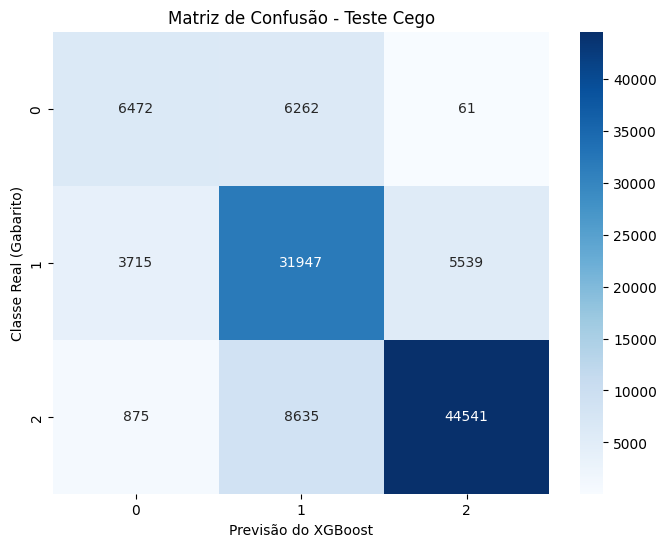

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Avaliando o modelo no futuro (Dados de Teste)...")

# Fazer a previsão nos dados que o modelo NUNCA viu
y_pred_final = best_model.predict(X_test)

# Relatório completo de métricas
print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred_final))

# Matriz de Confusão Visual
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Teste Cego')
plt.ylabel('Classe Real (Gabarito)')
plt.xlabel('Previsão do XGBoost')
plt.show()

In [12]:
# Salva o modelo otimizado no formato nativo do XGBoost
best_model.save_model("C:/Users/Gabriel/Documents/Projects/Global-Tension-Monitor/models/gtm_xgb_model.json")